# ETL E ANÁLISE EXPLORATÓRIA DE DADOS
## Extract, Transform, Load + Exploratory Data Analysis

**Objetivo:** 
1. Rotular sentimentos baseado nas notas
2. Balancear o dataset
3. Realizar análise exploratória completa
4. Salvar dados processados para próximas etapas

## 1. IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## 2. CARREGAR DADOS BRUTOS

In [2]:
# Listar arquivos disponíveis em data/raw
raw_files = os.listdir('../data/raw')
csv_files = [f for f in raw_files if f.endswith('.csv')]

print("📁 Arquivos disponíveis em data/raw:")
for i, file in enumerate(csv_files, 1):
    print(f"   {i}. {file}")

# Carregar o arquivo mais recente (ou especifique o nome)
latest_file = sorted(csv_files)[-1]  # Pega o mais recente
filepath = f'../data/raw/{latest_file}'

print(f"\n📂 Carregando: {latest_file}")
df = pd.read_csv(filepath)

print(f"\n✅ Dataset carregado: {len(df):,} reviews")
display(df.head())

📁 Arquivos disponíveis em data/raw:
   1. reviews_massivas_20260407_222537.csv

📂 Carregando: reviews_massivas_20260407_222537.csv

✅ Dataset carregado: 30,400 reviews


,texto,nota,data,app
0,É o melhor curço de inglês que eu já fiz .muit...,5,2026-04-06 22:18:31,Duolingo
1,um pouco limitado pra você conseguir bater um ...,3,2026-04-06 22:17:19,Duolingo
2,muito top de legal demais top,5,2026-04-06 22:17:14,Duolingo
3,"esse app é sensacional, vc não quer deixar de ...",5,2026-04-06 22:17:06,Duolingo
4,estou aprendendo muito,5,2026-04-06 22:16:35,Duolingo


## 3. ROTULAGEM DE SENTIMENTOS

**Critério:**
- **Positivo**: notas 4 ou 5 estrelas
- **Neutro**: nota 3 estrelas
- **Negativo**: notas 1 ou 2 estrelas

In [3]:
def rotular_sentimento(nota):
    """Rotula sentimento baseado na nota"""
    if nota >= 4:
        return 'Positivo'
    elif nota == 3:
        return 'Neutro'
    else:
        return 'Negativo'

# Aplicar rotulagem
df['sentimento'] = df['nota'].apply(rotular_sentimento)

print("="*80)
print("🏷️  ROTULAGEM DE SENTIMENTOS CONCLUÍDA")
print("="*80)
print(f"\nDistribuição ANTES do balanceamento:")
sentimento_counts = df['sentimento'].value_counts()
for sent, count in sentimento_counts.items():
    pct = (count / len(df)) * 100
    print(f"   {sent:10s}: {count:6,} ({pct:5.2f}%)")

print(f"\nTotal: {len(df):,} reviews")

🏷️  ROTULAGEM DE SENTIMENTOS CONCLUÍDA

Distribuição ANTES do balanceamento:
   Positivo  : 24,049 (79.11%)
   Negativo  :  5,088 (16.74%)
   Neutro    :  1,263 ( 4.15%)

Total: 30,400 reviews


## 4. BALANCEAMENTO DO DATASET

Usamos **undersampling** para equalizar as classes.

In [4]:
# Encontrar tamanho da classe minoritária
min_samples = df['sentimento'].value_counts().min()

print(f"🎯 Balanceando para {min_samples:,} amostras por classe...\n")

# Balancear
df_balanced = df.groupby('sentimento').sample(
    n=min_samples,
    random_state=42
).reset_index(drop=True)

print("="*80)
print("✅ BALANCEAMENTO CONCLUÍDO")
print("="*80)
print(f"\nDistribuição APÓS balanceamento:")
for sent, count in df_balanced['sentimento'].value_counts().items():
    print(f"   {sent:10s}: {count:6,} (33.33%)")

print(f"\nTotal: {len(df_balanced):,} reviews (antes: {len(df):,})")

🎯 Balanceando para 1,263 amostras por classe...

✅ BALANCEAMENTO CONCLUÍDO

Distribuição APÓS balanceamento:
   Negativo  :  1,263 (33.33%)
   Neutro    :  1,263 (33.33%)
   Positivo  :  1,263 (33.33%)

Total: 3,789 reviews (antes: 30,400)


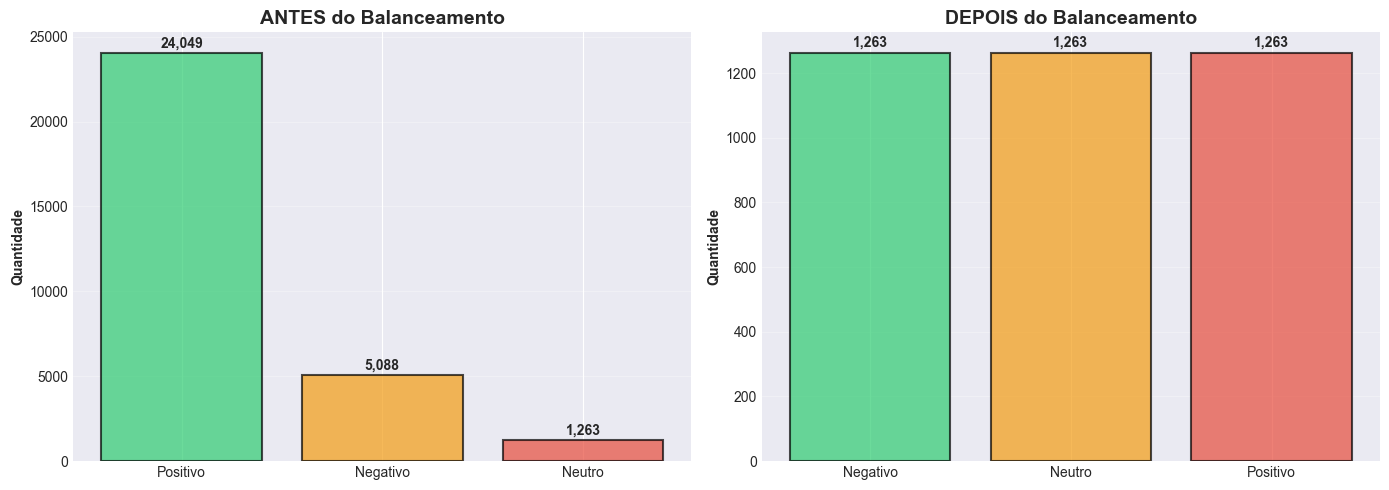

💾 Gráfico salvo: ../results/figures/02_balanceamento.png


In [5]:
# Visualizar balanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ANTES
counts_before = df['sentimento'].value_counts()
axes[0].bar(counts_before.index, counts_before.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_title('ANTES do Balanceamento', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Quantidade', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (sent, count) in enumerate(counts_before.items()):
    axes[0].text(i, count + 300, f'{count:,}', ha='center', fontweight='bold')

# DEPOIS
counts_after = df_balanced['sentimento'].value_counts()
axes[1].bar(counts_after.index, counts_after.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_title('DEPOIS do Balanceamento', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Quantidade', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (sent, count) in enumerate(counts_after.items()):
    axes[1].text(i, count + 20, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/02_balanceamento.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Gráfico salvo: ../results/figures/02_balanceamento.png")

##  5. ANÁLISE EXPLORATÓRIA DE DADOS (AED)

### 5.1 Estatísticas dos Textos

In [6]:
# Calcular métricas dos textos
df_balanced['tamanho'] = df_balanced['texto'].str.len()
df_balanced['palavras'] = df_balanced['texto'].str.split().str.len()

print("="*80)
print("📊 ESTATÍSTICAS DOS TEXTOS")
print("="*80)
print(f"\nGeral:")
print(f"   Tamanho médio: {df_balanced['tamanho'].mean():.0f} caracteres")
print(f"   Palavras médias: {df_balanced['palavras'].mean():.1f}")
print(f"   Menor: {df_balanced['tamanho'].min()} | Maior: {df_balanced['tamanho'].max()}")

print(f"\nPor sentimento:")
stats = df_balanced.groupby('sentimento')[['tamanho', 'palavras']].mean().round(1)
display(stats)

📊 ESTATÍSTICAS DOS TEXTOS

Geral:
   Tamanho médio: 100 caracteres
   Palavras médias: 17.6
   Menor: 1 | Maior: 656

Por sentimento:


,tamanho,palavras
sentimento,,
Negativo,109.6,19.3
Neutro,132.2,23.5
Positivo,58.6,10.1


### 5.2 Visualizações da AED

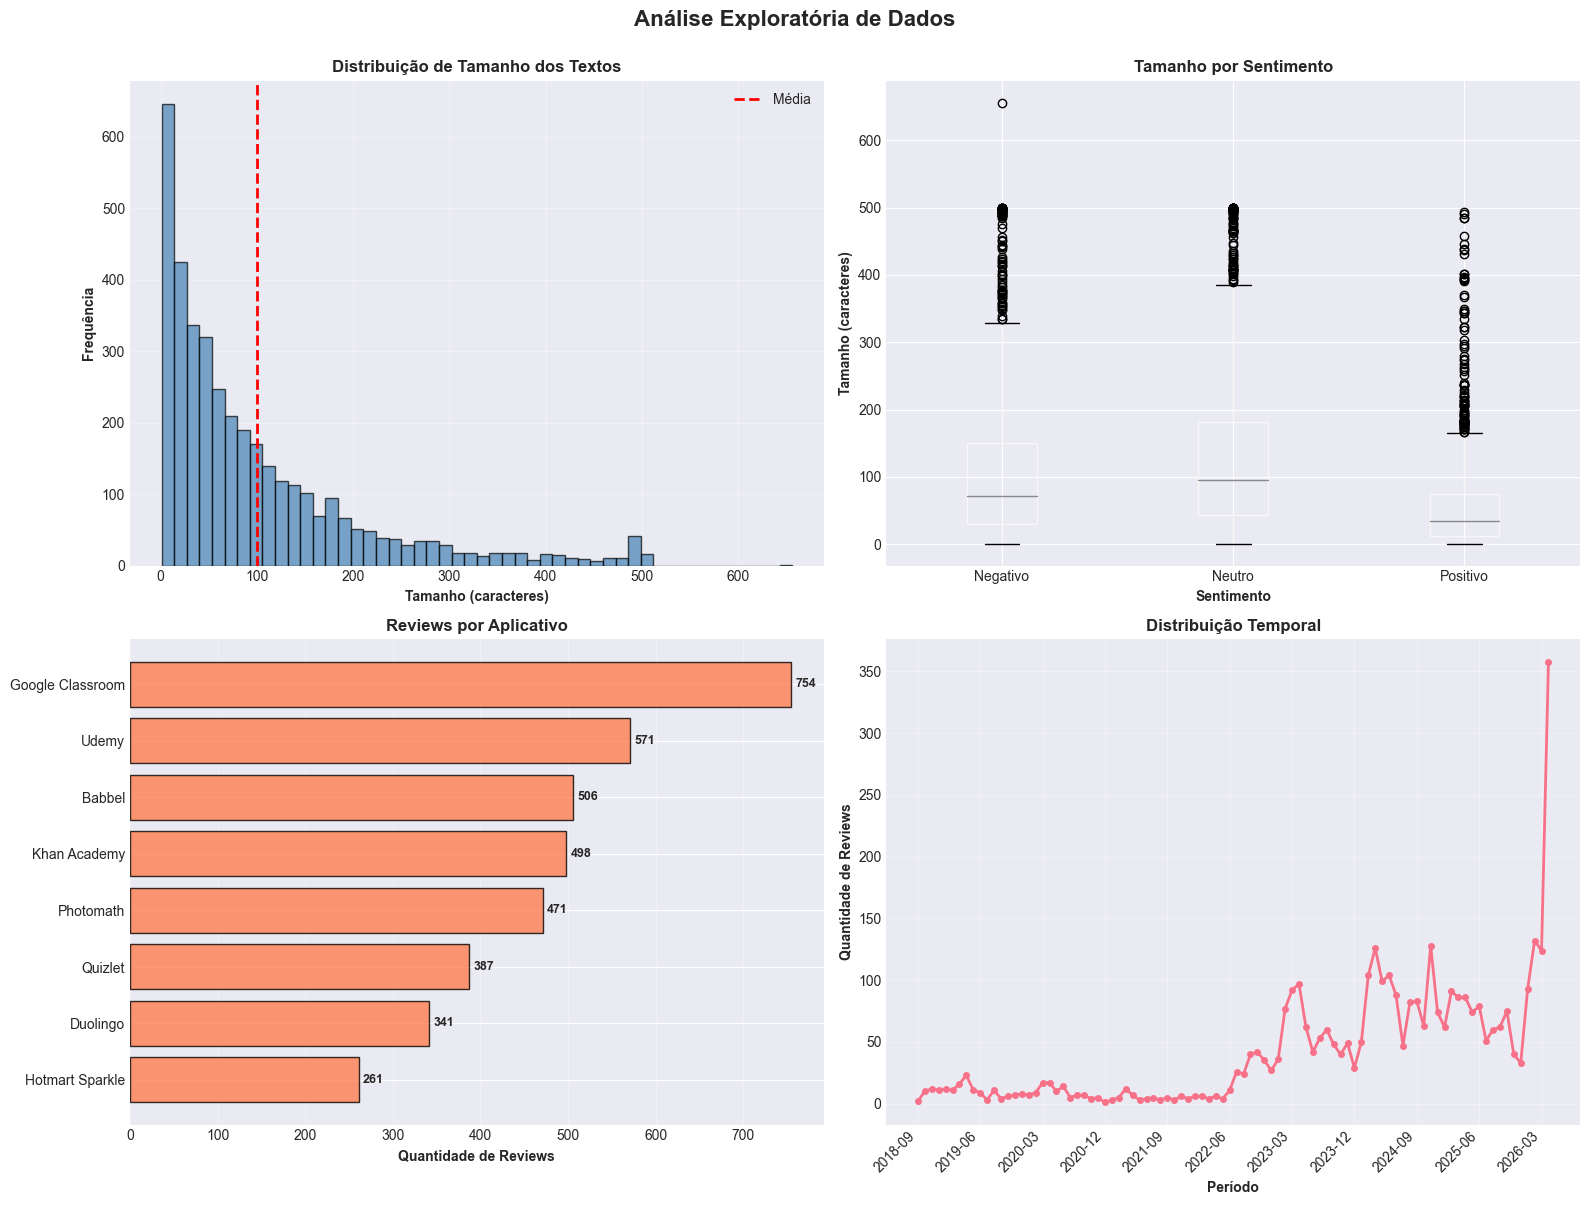

💾 Gráfico salvo: ../results/figures/02_aed_completa.png


In [7]:
# Criar figura com 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribuição de tamanho dos textos
axes[0, 0].hist(df_balanced['tamanho'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df_balanced['tamanho'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
axes[0, 0].set_xlabel('Tamanho (caracteres)', fontweight='bold')
axes[0, 0].set_ylabel('Frequência', fontweight='bold')
axes[0, 0].set_title('Distribuição de Tamanho dos Textos', fontweight='bold', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Boxplot: Tamanho por sentimento
df_balanced.boxplot(column='tamanho', by='sentimento', ax=axes[0, 1])
axes[0, 1].set_xlabel('Sentimento', fontweight='bold')
axes[0, 1].set_ylabel('Tamanho (caracteres)', fontweight='bold')
axes[0, 1].set_title('Tamanho por Sentimento', fontweight='bold', fontsize=12)
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Reviews por App
app_counts = df_balanced['app'].value_counts().sort_values(ascending=True)
axes[1, 0].barh(app_counts.index, app_counts.values, color='coral', alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Quantidade de Reviews', fontweight='bold')
axes[1, 0].set_title('Reviews por Aplicativo', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(app_counts.values):
    axes[1, 0].text(v + 5, i, str(v), va='center', fontweight='bold', fontsize=9)

# 4. Distribuição temporal
df_balanced['ano_mes'] = pd.to_datetime(df_balanced['data']).dt.to_period('M')
temporal = df_balanced['ano_mes'].value_counts().sort_index()
axes[1, 1].plot(temporal.index.astype(str), temporal.values, marker='o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Período', fontweight='bold')
axes[1, 1].set_ylabel('Quantidade de Reviews', fontweight='bold')
axes[1, 1].set_title('Distribuição Temporal', fontweight='bold', fontsize=12)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)
# Mostrar apenas alguns labels para não ficar poluído
n_labels = 10
step = max(1, len(temporal) // n_labels)
axes[1, 1].set_xticks(range(0, len(temporal), step))
axes[1, 1].set_xticklabels([temporal.index.astype(str)[i] for i in range(0, len(temporal), step)], rotation=45, ha='right')

plt.suptitle('Análise Exploratória de Dados', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/02_aed_completa.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Gráfico salvo: ../results/figures/02_aed_completa.png")

### 5.3 Nuvem de Palavras por Sentimento

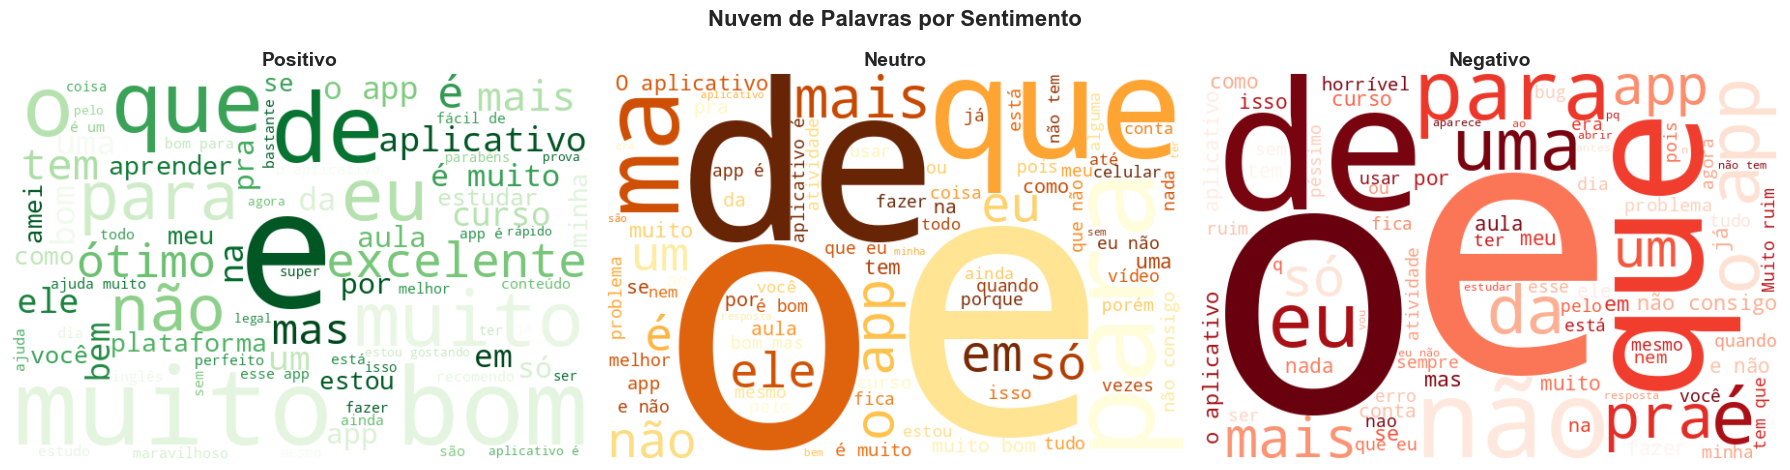

💾 Gráfico salvo: ../results/figures/02_wordclouds.png


In [8]:
# Função para gerar nuvem de palavras
def gerar_wordcloud(texto, titulo):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100,
        relative_scaling=0.5
    ).generate(texto)
    
    return wordcloud

# Criar nuvens para cada sentimento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentimentos = ['Positivo', 'Neutro', 'Negativo']
cores = ['Greens', 'YlOrBr', 'Reds']

for idx, (sent, cor) in enumerate(zip(sentimentos, cores)):
    # Concatenar todos os textos do sentimento
    texto_completo = ' '.join(df_balanced[df_balanced['sentimento'] == sent]['texto'].astype(str))
    
    # Gerar wordcloud
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap=cor,
        max_words=80
    ).generate(texto_completo)
    
    # Plotar
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{sent}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Nuvem de Palavras por Sentimento', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/02_wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Gráfico salvo: ../results/figures/02_wordclouds.png")

## 6. SALVAR DADOS PROCESSADOS

In [9]:
# Criar pasta processed se não existir
os.makedirs('../data/processed', exist_ok=True)

# Salvar dados balanceados
output_file = '../data/processed/reviews_balanceadas.csv'
df_balanced.to_csv(output_file, index=False, encoding='utf-8-sig')

print("="*80)
print("💾 DADOS PROCESSADOS SALVOS")
print("="*80)
print(f"📁 Arquivo: {output_file}")
print(f"📊 Linhas: {len(df_balanced):,}")
print(f"📊 Colunas: {list(df_balanced.columns)}")
print(f"💽 Tamanho: {os.path.getsize(output_file) / (1024*1024):.2f} MB")

print(f"\n✅ ETL e AED finalizados! Prossiga para o Notebook 3 (PLN)")

💾 DADOS PROCESSADOS SALVOS
📁 Arquivo: ../data/processed/reviews_balanceadas.csv
📊 Linhas: 3,789
📊 Colunas: ['texto', 'nota', 'data', 'app', 'sentimento', 'tamanho', 'palavras', 'ano_mes']
💽 Tamanho: 0.59 MB

✅ ETL e AED finalizados! Prossiga para o Notebook 3 (PLN)


## 7. RESUMO DA ANÁLISE

In [10]:
print("="*80)
print("📋 RESUMO DO NOTEBOOK 2")
print("="*80)

print(f"\n✅ Processos concluídos:")
print(f"   1. Rotulagem por notas (4-5=Pos, 3=Neu, 1-2=Neg)")
print(f"   2. Balanceamento por undersampling")
print(f"   3. Análise exploratória completa")
print(f"   4. Visualizações geradas")
print(f"   5. Dados salvos em data/processed/")

print(f"\n📊 Estatísticas finais:")
print(f"   Total de reviews: {len(df_balanced):,}")
print(f"   Sentimentos: 3 classes balanceadas")
print(f"   Tamanho médio: {df_balanced['tamanho'].mean():.0f} caracteres")
print(f"   Palavras médias: {df_balanced['palavras'].mean():.1f}")

print(f"\n📁 Arquivos gerados:")
print(f"   • ../data/processed/reviews_balanceadas.csv")
print(f"   • ../results/figures/02_balanceamento.png")
print(f"   • ../results/figures/02_aed_completa.png")
print(f"   • ../results/figures/02_wordclouds.png")

print(f"\n➡️  Próximo: Notebook 3 - Processamento de Linguagem Natural")

📋 RESUMO DO NOTEBOOK 2

✅ Processos concluídos:
   1. Rotulagem por notas (4-5=Pos, 3=Neu, 1-2=Neg)
   2. Balanceamento por undersampling
   3. Análise exploratória completa
   4. Visualizações geradas
   5. Dados salvos em data/processed/

📊 Estatísticas finais:
   Total de reviews: 3,789
   Sentimentos: 3 classes balanceadas
   Tamanho médio: 100 caracteres
   Palavras médias: 17.6

📁 Arquivos gerados:
   • ../data/processed/reviews_balanceadas.csv
   • ../results/figures/02_balanceamento.png
   • ../results/figures/02_aed_completa.png
   • ../results/figures/02_wordclouds.png

➡️  Próximo: Notebook 3 - Processamento de Linguagem Natural
